<a href="https://colab.research.google.com/github/iiiyahiya111/Project/blob/main/week_2_pilot_run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# ============================================================
# CHECK ACTUAL ZIP FILE NAMES
# ============================================================

from pathlib import Path

print("ZIP files in /content:\n")

for p in Path("/content").glob("*.zip"):
    print(p)

print("\nZIP files in Google Drive:\n")

for p in Path("/content/drive/MyDrive").rglob("*.zip"):
    print(p)

ZIP files in /content:

/content/Potato_Severity_Dataset_DEDUPED_FINAL.zip

ZIP files in Google Drive:

/content/drive/MyDrive/Win 11 Activator.zip
/content/drive/MyDrive/Crop Disease Segmentation.v1i.coco-segmentation.zip
/content/drive/MyDrive/Potato_Severity_Dataset.zip
/content/drive/MyDrive/Dataset_1_Image_Environment.zip
/content/drive/MyDrive/Potato_Severity_Dataset_DEDUPED_FINAL.zip
/content/drive/MyDrive/2.2 ICE/dado.zip
/content/drive/MyDrive/Rice_Disease_Project/Rice Leaf Disease Image Samples.zip
/content/drive/MyDrive/Rice_Disease_Project/Rice_Leaf_Disease_Segmentation_Masks.zip


In [15]:
from pathlib import Path
import os

print("ZIP in /content:")
zip_local = Path("/content/Potato_Severity_Dataset_DEDUPED_FINAL.zip")
print(zip_local)
print("Exists:", zip_local.exists())
print("Size MB:", zip_local.stat().st_size / (1024**2) if zip_local.exists() else "N/A")

print("\n/content/drive status:")
print("Exists:", Path("/content/drive").exists())
print("Actual mount:", os.path.ismount("/content/drive"))

print("\nMyDrive exists:")
print(Path("/content/drive/MyDrive").exists())

ZIP in /content:
/content/Potato_Severity_Dataset_DEDUPED_FINAL.zip
Exists: True
Size MB: 0.00016498565673828125

/content/drive status:
Exists: True
Actual mount: True

MyDrive exists:
True


In [16]:
# ============================================================
# FIX GOOGLE DRIVE MOUNT + VERIFY REAL DATASET ZIP
# ============================================================

import os
import shutil
from pathlib import Path

from google.colab import drive


DRIVE_MOUNT = Path("/content/drive")
DRIVE_ROOT = DRIVE_MOUNT / "MyDrive"

ZIP_NAME = "Potato_Severity_Dataset_DEDUPED_FINAL.zip"


print("=" * 70)
print("GOOGLE DRIVE MOUNT REPAIR")
print("=" * 70)

print(
    "Current /content/drive exists:",
    DRIVE_MOUNT.exists()
)

print(
    "Current /content/drive is actual mount:",
    os.path.ismount(str(DRIVE_MOUNT))
)


# ------------------------------------------------------------
# Remove stale mount directory ONLY if it is not a real mount
# ------------------------------------------------------------

if DRIVE_MOUNT.exists() and not os.path.ismount(
    str(DRIVE_MOUNT)
):

    print(
        "\nStale /content/drive detected."
    )

    print(
        "Removing stale directory..."
    )

    shutil.rmtree(
        DRIVE_MOUNT,
        ignore_errors=True
    )

    print(
        "Stale directory removed."
    )


# ------------------------------------------------------------
# Mount Google Drive
# ------------------------------------------------------------

print(
    "\nMounting Google Drive..."
)

drive.mount(
    str(DRIVE_MOUNT),
    force_remount=True
)


# ------------------------------------------------------------
# Verify mount
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MOUNT VERIFICATION")
print("=" * 70)

print(
    "Mountpoint exists:",
    DRIVE_MOUNT.exists()
)

print(
    "Actual mount:",
    os.path.ismount(
        str(DRIVE_MOUNT)
    )
)

print(
    "MyDrive exists:",
    DRIVE_ROOT.exists()
)


if not os.path.ismount(
    str(DRIVE_MOUNT)
):

    raise RuntimeError(
        "Google Drive still did not mount correctly."
    )


# ------------------------------------------------------------
# Check the REAL ZIP
# ------------------------------------------------------------

ZIP_PATH = DRIVE_ROOT / ZIP_NAME

print("\n" + "=" * 70)
print("REAL DATASET ZIP CHECK")
print("=" * 70)

print(
    "Expected ZIP:"
)

print(
    ZIP_PATH
)

print(
    "Exists:",
    ZIP_PATH.exists()
)


if not ZIP_PATH.exists():

    print(
        "\nZIP not found at the expected MyDrive location."
    )

    print(
        "\nZIP files found directly under MyDrive:"
    )

    for p in sorted(
        DRIVE_ROOT.glob("*.zip")
    ):
        print(
            " -",
            p
        )

    print(
        "\nZIP files found recursively:"
    )

    for p in sorted(
        DRIVE_ROOT.rglob("*.zip")
    ):
        print(
            " -",
            p
        )

    raise FileNotFoundError(
        f"\nCould not find:\n{ZIP_PATH}"
    )


# ------------------------------------------------------------
# Verify file size
# ------------------------------------------------------------

size_mb = (
    ZIP_PATH.stat().st_size
    /
    (1024 ** 2)
)

print(
    f"\nZIP size: {size_mb:.2f} MB"
)


if size_mb < 1:

    raise RuntimeError(
        "\nThe ZIP found is suspiciously small "
        f"({size_mb:.6f} MB)."
    )


print(
    "\nSUCCESS:"
)

print(
    "The real Google Drive ZIP is accessible."
)

print(
    f"ZIP_PATH = '{ZIP_PATH}'"
)

GOOGLE DRIVE MOUNT REPAIR
Current /content/drive exists: True
Current /content/drive is actual mount: True

Mounting Google Drive...
Mounted at /content/drive

MOUNT VERIFICATION
Mountpoint exists: True
Actual mount: True
MyDrive exists: True

REAL DATASET ZIP CHECK
Expected ZIP:
/content/drive/MyDrive/Potato_Severity_Dataset_DEDUPED_FINAL.zip
Exists: True

ZIP size: 22.18 MB

SUCCESS:
The real Google Drive ZIP is accessible.
ZIP_PATH = '/content/drive/MyDrive/Potato_Severity_Dataset_DEDUPED_FINAL.zip'


# **SECTION 1 — Dataset Setup, Extraction and Strict QC**

In [19]:
# ============================================================
# SECTION 1 — Dataset Setup, Extraction and Strict QC
# ============================================================

import os
import sys
import json
import math
import random
import shutil
import zipfile
import subprocess
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = False


# ============================================================
# 1. CONFIGURATION
# ============================================================

# VERIFIED Google Drive path
ZIP_PATH = Path(
    "/content/drive/MyDrive/"
    "Potato_Severity_Dataset_DEDUPED_FINAL.zip"
)

# Working extraction directory.
# This does NOT modify the original ZIP.
EXTRACT_DIR = Path(
    "/content/potato_week2_extracted"
)

# Experiment outputs
OUTPUT_DIR = Path(
    "/content/drive/MyDrive/"
    "Week2_Potato_Baseline_Outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SEED = 42

EXPECTED_COUNTS = {
    "train": 895,
    "valid": 107,
    "test": 106,
}

EXPECTED_TOTAL = 1108

# Existing Week 1 B1 pilot result
WEEK1_PILOT = {
    "mIoU": 0.9135055582,
    "Lesion IoU": 0.8376114750,
    "Boundary F1": 0.7802665233,
    "Loss": 0.6045852585,
    "N_images": 106,
}

WEEK1_DATASET_SIZE_NOTE = (
    "Pilot subset; exact total/training subset size "
    "was not available in the stored result."
)

IMAGE_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
}

SPLIT_ALIASES = {
    "train": ["train"],
    "valid": ["valid", "val", "validation"],
    "test": ["test"],
}


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


seed_everything(SEED)


# ============================================================
# 3. VERIFY GOOGLE DRIVE MOUNT
# ============================================================

print("=" * 70)
print("GOOGLE DRIVE / ZIP VERIFICATION")
print("=" * 70)

print(
    f"ZIP path:\n{ZIP_PATH}"
)

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        f"Verified ZIP path is not accessible:\n{ZIP_PATH}"
    )

if not ZIP_PATH.is_file():
    raise RuntimeError(
        f"ZIP path is not a file:\n{ZIP_PATH}"
    )

zip_size_mb = (
    ZIP_PATH.stat().st_size
    / (1024 ** 2)
)

print(
    f"ZIP exists : True"
)

print(
    f"ZIP size   : {zip_size_mb:.2f} MB"
)

if zip_size_mb < 1:
    raise RuntimeError(
        "The ZIP file is unexpectedly small. "
        "Expected approximately 22 MB."
    )


# ============================================================
# 4. CHECK ZIP INTEGRITY
# ============================================================

print("\n" + "=" * 70)
print("ZIP INTEGRITY CHECK")
print("=" * 70)

try:

    with zipfile.ZipFile(
        ZIP_PATH,
        "r",
    ) as zf:

        bad_file = zf.testzip()

        if bad_file is not None:
            raise RuntimeError(
                f"Corrupt ZIP member detected:\n{bad_file}"
            )

        zip_members = zf.infolist()

        print(
            "ZIP integrity : OK"
        )

        print(
            f"ZIP members   : {len(zip_members):,}"
        )

except zipfile.BadZipFile as e:

    raise RuntimeError(
        f"Invalid/corrupt ZIP file:\n{e}"
    )


# ============================================================
# 5. OPTIONAL OPENCV CHECK
# ============================================================

try:

    import cv2

except ImportError:

    print(
        "\nOpenCV not found. Installing..."
    )

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "opencv-python-headless",
    ])

    import cv2


# ============================================================
# 6. SAFE ZIP EXTRACTION
# ============================================================

print("\n" + "=" * 70)
print("EXTRACTING DATASET")
print("=" * 70)


def safe_extract_zip(
    zip_path,
    extract_dir,
):

    zip_path = Path(zip_path)
    extract_dir = Path(extract_dir)

    if not zip_path.exists():
        raise FileNotFoundError(
            f"ZIP not found:\n{zip_path}"
        )

    # Delete only our previous working extraction.
    # The original Drive ZIP remains untouched.
    if extract_dir.exists():

        print(
            f"Removing previous working extraction:\n"
            f"{extract_dir}"
        )

        shutil.rmtree(
            extract_dir
        )

    extract_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as zf:

        root = extract_dir.resolve()

        # Zip-slip protection
        for info in zf.infolist():

            target = (
                extract_dir /
                info.filename
            ).resolve()

            if os.path.commonpath([
                str(root),
                str(target),
            ]) != str(root):

                raise RuntimeError(
                    f"Unsafe ZIP member detected:\n"
                    f"{info.filename}"
                )

        zf.extractall(
            extract_dir
        )

    print(
        f"Extraction completed:\n"
        f"{extract_dir}"
    )


safe_extract_zip(
    ZIP_PATH,
    EXTRACT_DIR
)


# ============================================================
# 7. DATASET ROOT DISCOVERY
# ============================================================

print("\n" + "=" * 70)
print("DATASET ROOT DISCOVERY")
print("=" * 70)


def find_split_dir(
    root,
    canonical_split,
):

    for alias in SPLIT_ALIASES[
        canonical_split
    ]:

        candidate = (
            root /
            alias
        )

        if (
            candidate /
            "images"
        ).is_dir():

            return candidate

    return None


def find_dataset_root(
    extract_dir,
):

    candidates = [
        extract_dir
    ] + [
        p
        for p in extract_dir.rglob("*")
        if p.is_dir()
    ]

    for candidate in candidates:

        found = {
            split:
            find_split_dir(
                candidate,
                split
            )
            for split in [
                "train",
                "valid",
                "test",
            ]
        }

        if all(found.values()):

            return candidate

    raise FileNotFoundError(
        "Could not automatically identify a dataset root "
        "containing train/valid/test/images."
    )


DATASET_ROOT = find_dataset_root(
    EXTRACT_DIR
)

print(
    "Detected dataset root:"
)

print(
    DATASET_ROOT
)


# ============================================================
# 8. LOCATE CSV METADATA
# ============================================================

print("\n" + "=" * 70)
print("CSV METADATA")
print("=" * 70)

csv_candidates = list(
    DATASET_ROOT.rglob(
        "potato_severity_FINAL.csv"
    )
)

CSV_PATH = (
    csv_candidates[0]
    if csv_candidates
    else None
)

CSV_DF = None
CSV_INDEX = {}

if CSV_PATH is not None:

    try:

        CSV_DF = pd.read_csv(
            CSV_PATH
        )

        def csv_stem(value):

            if pd.isna(value):
                return ""

            return Path(
                str(value)
                .replace("\\", "/")
            ).stem.lower()

        for _, row in (
            CSV_DF.iterrows()
        ):

            split = str(
                row.get(
                    "split",
                    ""
                )
            ).strip().lower()

            filename_key = csv_stem(
                row.get(
                    "filename",
                    ""
                )
            )

            if filename_key:

                CSV_INDEX[
                    (split, filename_key)
                ] = row.to_dict()

        print(
            f"CSV found : {CSV_PATH}"
        )

        print(
            f"CSV rows  : {len(CSV_DF):,}"
        )

    except Exception as e:

        print(
            "CSV could not be read."
        )

        print(
            f"Reason: {e}"
        )

else:

    print(
        "potato_severity_FINAL.csv not found."
    )

    print(
        "Continuing with filesystem-based QC."
    )


# ============================================================
# 9. FILE HELPERS
# ============================================================

def normalize_stem(path):
    stem = Path(path).stem.lower()
    # Remove common mask suffixes to align stems across image and masks
    if stem.endswith("_leaf"):
        stem = stem[:-5] # remove "_leaf"
    # If lesion masks also have a suffix like "_mask", add a similar check:
    # elif stem.endswith("_mask"):
    #     stem = stem[:-5] # remove "_mask"
    return stem


def scan_files(
    folder,
):

    folder = Path(folder)

    if not folder.exists():
        return []

    return sorted([
        p
        for p in folder.rglob("*")
        if (
            p.is_file()
            and
            p.suffix.lower()
            in IMAGE_EXTS
        )
    ])


def unique_stem_map(
    files,
):

    mapping = {}
    duplicates = defaultdict(list)

    for p in files:

        key = normalize_stem(
            p
        )

        if key in mapping:

            if not duplicates[key]:

                duplicates[key].append(
                    mapping[key]
                )

            duplicates[key].append(
                p
            )

        else:

            mapping[key] = p

    return (
        mapping,
        duplicates
    )


def inspect_file(
    path,
    is_mask=False,
):

    """
    Returns:
        valid
        shape_hw
        nonzero
        binary_like
        error_string
    """

    if path is None:

        return (
            False,
            None,
            False,
            False,
            "missing"
        )

    try:

        # Verify image integrity first.
        with Image.open(path) as im:
            im.verify()

        # Re-open after verify().
        with Image.open(path) as im:

            if is_mask:

                arr = np.asarray(
                    im.convert("L")
                )

            else:

                arr = np.asarray(
                    im.convert("RGB")
                )

        shape_hw = tuple(
            arr.shape[:2]
        )

        nonzero = bool(
            np.count_nonzero(arr)
        )

        binary_like = True

        if is_mask:

            unique_values = np.unique(
                arr
            )

            binary_like = (
                len(unique_values) <= 2
            )

        return (
            True,
            shape_hw,
            nonzero,
            binary_like,
            ""
        )

    except Exception as e:

        return (
            False,
            None,
            False,
            False,
            str(e)
        )


def get_csv_metadata(
    split,
    stem,
):

    row = CSV_INDEX.get(
        (
            split.lower(),
            stem,
        )
    )

    if row is None:

        row = CSV_INDEX.get(
            (
                "",
                stem,
            )
        )

    return row


# ============================================================
# 10. AUDIT EACH SPLIT
# ============================================================

print("\n" + "=" * 70)
print("DATASET AUDIT")
print("=" * 70)

audit_rows = []
split_image_stems = {}

for split in [
    "train",
    "valid",
    "test",
]:

    split_dir = find_split_dir(
        DATASET_ROOT,
        split
    )

    if split_dir is None:

        print(
            f"\nWARNING: {split} directory not found."
        )

        continue

    image_files = scan_files(
        split_dir /
        "images"
    )

    lesion_files = scan_files(
        split_dir /
        "lesion_masks"
    )

    leaf_files = scan_files(
        split_dir /
        "leaf_masks"
    )

    image_map, image_dups = (
        unique_stem_map(
            image_files
        )
    )

    lesion_map, lesion_dups = (
        unique_stem_map(
            lesion_files
        )
    )

    leaf_map, leaf_dups = (
        unique_stem_map(
            leaf_files
        )
    )

    split_image_stems[
        split
    ] = set(
        image_map.keys()
    )

    print("\n" + "-" * 70)

    print(
        f"Split: {split}"
    )

    print(
        f"Images         : {len(image_files)}"
    )

    print(
        f"Lesion masks   : {len(lesion_files)}"
    )

    print(
        f"Leaf masks     : {len(leaf_files)}"
    )

    print(
        f"Image duplicates : {len(image_dups)}"
    )

    print(
        f"Lesion duplicates: {len(lesion_dups)}"
    )

    print(
        f"Leaf duplicates  : {len(leaf_dups)}"
    )

    all_stems = (
        set(image_map.keys())
        |
        set(lesion_map.keys())
        |
        set(leaf_map.keys())
    )

    for stem in sorted(
        all_stems
    ):

        image_path = image_map.get(
            stem
        )

        lesion_path = lesion_map.get(
            stem
        )

        leaf_path = leaf_map.get(
            stem
        )

        issues = []

        # ----------------------------------------------------
        # Missing files
        # ----------------------------------------------------

        if image_path is None:

            issues.append(
                "missing_image"
            )

        if lesion_path is None:

            issues.append(
                "missing_lesion_mask"
            )

        if leaf_path is None:

            issues.append(
                "missing_leaf_mask"
            )

        # ----------------------------------------------------
        # Validate image
        # ----------------------------------------------------

        (
            image_valid,
            image_shape,
            _,
            _,
            image_error,
        ) = inspect_file(
            image_path,
            is_mask=False
        )

        # ----------------------------------------------------
        # Validate lesion mask
        # ----------------------------------------------------

        (
            lesion_valid,
            lesion_shape,
            lesion_nonzero,
            lesion_binary,
            lesion_error,
        ) = inspect_file(
            lesion_path,
            is_mask=True
        )

        # ----------------------------------------------------
        # Validate leaf mask
        # ----------------------------------------------------

        (
            leaf_valid,
            leaf_shape,
            leaf_nonzero,
            leaf_binary,
            leaf_error,
        ) = inspect_file(
            leaf_path,
            is_mask=True
        )

        # ----------------------------------------------------
        # Corrupt files
        # ----------------------------------------------------

        if (
            not image_valid
            and
            image_path is not None
        ):

            issues.append(
                "corrupt_or_invalid_image"
            )

        if (
            not lesion_valid
            and
            lesion_path is not None
        ):

            issues.append(
                "corrupt_or_invalid_lesion_mask"
            )

        if (
            not leaf_valid
            and
            leaf_path is not None
        ):

            issues.append(
                "corrupt_or_invalid_leaf_mask"
            )

        # ----------------------------------------------------
        # Image/mask dimensions
        # ----------------------------------------------------

        dimension_ok = (
            image_shape is not None
            and lesion_shape is not None
            and leaf_shape is not None
            and
            image_shape
            ==
            lesion_shape
            ==
            leaf_shape
        )

        if (
            image_valid
            and lesion_valid
            and leaf_valid
            and not dimension_ok
        ):

            issues.append(
                "dimension_mismatch"
            )

        # ----------------------------------------------------
        # Binary masks
        # ----------------------------------------------------

        if (
            lesion_valid
            and not lesion_binary
        ):

            issues.append(
                "non_binary_lesion_mask"
            )

        if (
            leaf_valid
            and not leaf_binary
        ):

            issues.append(
                "non_binary_leaf_mask"
            )

        # ----------------------------------------------------
        # CSV metadata
        # ----------------------------------------------------

        metadata = get_csv_metadata(
            split,
            stem
        )

        class_name = ""
        severity_percent = np.nan
        final_decision = ""

        if metadata:

            class_name = str(
                metadata.get(
                    "class_name",
                    ""
                )
            ).strip()

            try:

                severity_percent = float(
                    metadata.get(
                        "severity_percent",
                        np.nan
                    )
                )

            except Exception:

                severity_percent = np.nan

            final_decision = str(
                metadata.get(
                    "final_decision",
                    ""
                )
            ).strip()

        class_lower = (
            class_name.lower()
        )

        # ----------------------------------------------------
        # Label consistency checks
        # ----------------------------------------------------

        healthy_nonzero = (
            "healthy" in class_lower
            and
            lesion_valid
            and
            lesion_nonzero
        )

        late_zero = (
            (
                "late" in class_lower
                and
                "blight" in class_lower
            )
            and
            lesion_valid
            and
            not lesion_nonzero
        )

        if healthy_nonzero:

            issues.append(
                "healthy_with_nonzero_lesion_mask"
            )

        if late_zero:

            issues.append(
                "late_blight_with_zero_lesion_mask"
            )

        # ----------------------------------------------------
        # Structural usability
        #
        # IMPORTANT:
        # Healthy images with empty lesion masks ARE valid
        # segmentation samples, so empty lesion masks are
        # reported but not automatically excluded.
        # ----------------------------------------------------

        usable = (
            image_path is not None
            and
            lesion_path is not None
            and
            leaf_path is not None
            and
            image_valid
            and
            lesion_valid
            and
            leaf_valid
            and
            dimension_ok
        )

        audit_rows.append({

            "split":
                split,

            "filename":
                (
                    image_path.name
                    if image_path
                    else stem
                ),

            "stem":
                stem,

            "image_path":
                (
                    str(image_path)
                    if image_path
                    else ""
                ),

            "lesion_mask_path":
                (
                    str(lesion_path)
                    if lesion_path
                    else ""
                ),

            "leaf_mask_path":
                (
                    str(leaf_path)
                    if leaf_path
                    else ""
                ),

            "class_name":
                class_name,

            "severity_percent":
                severity_percent,

            "final_decision":
                final_decision,

            "image_valid":
                image_valid,

            "lesion_mask_valid":
                lesion_valid,

            "leaf_mask_valid":
                leaf_valid,

            "image_shape":
                str(image_shape),

            "lesion_shape":
                str(lesion_shape),

            "leaf_shape":
                str(leaf_shape),

            "dimension_ok":
                dimension_ok,

            "lesion_nonzero":
                lesion_nonzero,

            "leaf_nonzero":
                leaf_nonzero,

            "lesion_binary":
                lesion_binary,

            "leaf_binary":
                leaf_binary,

            "healthy_nonzero":
                healthy_nonzero,

            "late_zero":
                late_zero,

            "usable":
                usable,

            "issues":
                ";".join(issues),
        })


# ============================================================
# 11. CROSS-SPLIT DUPLICATE CHECK
# ============================================================

print("\n" + "=" * 70)
print("CROSS-SPLIT DUPLICATE CHECK")
print("=" * 70)

cross_split_duplicates = {}

splits_present = list(
    split_image_stems.keys()
)

for i in range(
    len(splits_present)
):

    for j in range(
        i + 1,
        len(splits_present)
    ):

        s1 = splits_present[i]
        s2 = splits_present[j]

        overlap = (
            split_image_stems[s1]
            &
            split_image_stems[s2]
        )

        if overlap:

            cross_split_duplicates[
                f"{s1}__{s2}"
            ] = sorted(
                overlap
            )


if cross_split_duplicates:

    for pair, names in (
        cross_split_duplicates.items()
    ):

        print(
            f"{pair}: "
            f"{len(names)} duplicate filename stems"
        )

        print(
            names[:20]
        )

else:

    print(
        "No duplicate image filename stems "
        "across train/valid/test."
    )


# ============================================================
# 12. FINAL QC REPORT
# ============================================================

QC_DF = pd.DataFrame(
    audit_rows
)

if len(QC_DF) == 0:

    raise RuntimeError(
        "No dataset records were discovered."
    )


usable_by_split = (
    QC_DF[
        QC_DF["usable"]
    ]
    .groupby("split")
    .size()
    .to_dict()
)


print("\n" + "=" * 70)
print("FINAL QC REPORT")
print("=" * 70)


for split in [
    "train",
    "valid",
    "test",
]:

    total = int(
        (
            QC_DF["split"]
            ==
            split
        ).sum()
    )

    usable = int(
        usable_by_split.get(
            split,
            0
        )
    )

    expected = EXPECTED_COUNTS[
        split
    ]

    print(
        f"{split:>5} | "
        f"discovered={total:4d} | "
        f"usable={usable:4d} | "
        f"expected={expected}"
    )


print(
    f"\nTotal discovered : "
    f"{len(QC_DF)}"
)

print(
    f"Total usable     : "
    f"{int(QC_DF['usable'].sum())}"
)

print(
    f"Expected total   : "
    f"{EXPECTED_TOTAL}"
)


# ============================================================
# 13. MISSING / INVALID COUNTS
# ============================================================

print(
    "\nMissing / invalid samples:"
)

issue_cols = [
    "missing_image",
    "missing_lesion_mask",
    "missing_leaf_mask",
    "corrupt_or_invalid_image",
    "corrupt_or_invalid_lesion_mask",
    "corrupt_or_invalid_leaf_mask",
    "dimension_mismatch",
]


for issue in issue_cols:

    count = int(
        QC_DF[
            "issues"
        ]
        .fillna("")
        .str.contains(
            issue,
            regex=False
        )
        .sum()
    )

    print(
        f"  {issue:35s}: "
        f"{count}"
    )


# ============================================================
# 14. MASK / LABEL QC
# ============================================================

print(
    "\nMask / label QC:"
)

valid_lesion_masks = QC_DF[
    QC_DF[
        "lesion_mask_valid"
    ]
]

valid_leaf_masks = QC_DF[
    QC_DF[
        "leaf_mask_valid"
    ]
]

empty_lesion_count = int(
    (
        ~valid_lesion_masks[
            "lesion_nonzero"
        ]
    ).sum()
)

healthy_nonzero_count = int(
    QC_DF[
        "healthy_nonzero"
    ].sum()
)

late_zero_count = int(
    QC_DF[
        "late_zero"
    ].sum()
)

nonbinary_lesion_count = int(
    (
        valid_lesion_masks[
            "lesion_binary"
        ]
        ==
        False
    ).sum()
)

nonbinary_leaf_count = int(
    (
        valid_leaf_masks[
            "leaf_binary"
        ]
        ==
        False
    ).sum()
)


print(
    f"  Empty lesion masks             : "
    f"{empty_lesion_count}"
)

print(
    f"  Healthy + non-zero lesion mask : "
    f"{healthy_nonzero_count}"
)

print(
    f"  Late-blight + zero lesion mask : "
    f"{late_zero_count}"
)

print(
    f"  Non-binary lesion masks        : "
    f"{nonbinary_lesion_count}"
)

print(
    f"  Non-binary leaf masks          : "
    f"{nonbinary_leaf_count}"
)


# ============================================================
# 15. EXCLUDED SAMPLES
# ============================================================

excluded = QC_DF[
    ~QC_DF["usable"]
].copy()


if len(excluded):

    print(
        "\nSamples excluded from modeling "
        "because required structural QC failed:"
    )

    display(
        excluded[
            [
                "split",
                "filename",
                "issues",
                "image_shape",
                "lesion_shape",
                "leaf_shape",
            ]
        ].head(40)
    )

    if len(excluded) > 40:

        print(
            f"... and "
            f"{len(excluded)-40} "
            f"additional excluded samples."
        )

else:

    print(
        "\nNo samples excluded by "
        "structural/corruption QC."
    )


# ============================================================
# 16. SAVE QC AUDIT
# ============================================================

qc_path = (
    OUTPUT_DIR /
    "week2_dataset_qc_audit.csv"
)

QC_DF.to_csv(
    qc_path,
    index=False
)

print(
    f"\nQC audit saved to:\n{qc_path}"
)


# ============================================================
# 17. PREPARE RECORDS FOR NEXT SECTIONS
# ============================================================

USABLE_RECORDS = {

    split:
        QC_DF[
            (QC_DF["split"] == split)
            &
            (QC_DF["usable"])
        ].to_dict("records")

    for split in [
        "train",
        "valid",
        "test",
    ]
}


print(
    "\nUsable records passed forward:"
)

for split, records in (
    USABLE_RECORDS.items()
):

    print(
        f"  {split:>5}: "
        f"{len(records)}"
    )


# ============================================================
# 18. SECTION 1 STATUS
# ============================================================

print("\n" + "=" * 70)
print("SECTION 1 COMPLETE")
print("=" * 70)

print(
    f"Dataset root : {DATASET_ROOT}"
)

print(
    f"ZIP used     : {ZIP_PATH}"
)

print(
    f"Train        : "
    f"{len(USABLE_RECORDS['train'])}"
)

print(
    f"Validation   : "
    f"{len(USABLE_RECORDS['valid'])}"
)

print(
    f"Test         : "
    f"{len(USABLE_RECORDS['test'])}"
)

print(
    "\nOriginal ZIP was not modified."
)

print(
    "Only the extracted working copy and QC audit "
    "were created."
)


GOOGLE DRIVE / ZIP VERIFICATION
ZIP path:
/content/drive/MyDrive/Potato_Severity_Dataset_DEDUPED_FINAL.zip
ZIP exists : True
ZIP size   : 22.18 MB

ZIP INTEGRITY CHECK
ZIP integrity : OK
ZIP members   : 3,330

EXTRACTING DATASET
Removing previous working extraction:
/content/potato_week2_extracted
Extraction completed:
/content/potato_week2_extracted

DATASET ROOT DISCOVERY
Detected dataset root:
/content/potato_week2_extracted/Potato_Severity_Dataset_FINAL/segmentation

CSV METADATA
potato_severity_FINAL.csv not found.
Continuing with filesystem-based QC.

DATASET AUDIT

----------------------------------------------------------------------
Split: train
Images         : 895
Lesion masks   : 895
Leaf masks     : 895
Image duplicates : 0
Lesion duplicates: 0
Leaf duplicates  : 0

----------------------------------------------------------------------
Split: valid
Images         : 107
Lesion masks   : 107
Leaf masks     : 107
Image duplicates : 0
Lesion duplicates: 0
Leaf duplicates  : 0


# **SECTION 2 — Preprocessing, Dataset Class and DataLoader**

In [20]:
# ============================================================
# SECTION 2 — Preprocessing, Dataset Class and DataLoader
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

# -----------------------------
# 1. Reproducible preprocessing configuration
# -----------------------------
IMAGE_SIZE = 256

BATCH_SIZE = 16

NUM_WORKERS = min(
    2,
    max(0, (os.cpu_count() or 2) // 2)
)

PIN_MEMORY = torch.cuda.is_available()

# ImageNet normalization is used because EfficientNet-B0
# is initialized from ImageNet-pretrained weights.
#
# IMPORTANT:
# This is an explicit assumption because the exact Week 1
# normalization setting was not included in the specification.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# -----------------------------
# 2. Albumentations pipelines
# -----------------------------
def build_train_transform():
    return A.Compose([
        A.Resize(
            height=IMAGE_SIZE,
            width=IMAGE_SIZE,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
        ),

        # Training-only spatial augmentation.
        A.HorizontalFlip(p=0.50),
        A.VerticalFlip(p=0.20),
        A.RandomRotate90(p=0.30),

        # Moderate geometric perturbation.
        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=0.10,
            rotate_limit=15,
            border_mode=cv2.BORDER_REFLECT_101,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
            p=0.40,
        ),

        # Image-only augmentation.
        A.RandomBrightnessContrast(
            brightness_limit=0.15,
            contrast_limit=0.15,
            p=0.20,
        ),

        A.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
            max_pixel_value=255.0,
        ),

        ToTensorV2(),
    ])


def build_eval_transform():
    return A.Compose([
        A.Resize(
            height=IMAGE_SIZE,
            width=IMAGE_SIZE,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
        ),

        A.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
            max_pixel_value=255.0,
        ),

        ToTensorV2(),
    ])


# -----------------------------
# 3. Dataset class
# -----------------------------
class PotatoLesionDataset(Dataset):

    def __init__(self, records, transform=None):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]

        image_path = record["image_path"]
        lesion_mask_path = record["lesion_mask_path"]

        try:
            image = np.asarray(
                Image.open(image_path).convert("RGB")
            )

            lesion_mask = np.asarray(
                Image.open(lesion_mask_path).convert("L")
            )

        except Exception as e:
            raise RuntimeError(
                f"Failed loading sample {record['filename']}:\n"
                f"Image: {image_path}\n"
                f"Mask : {lesion_mask_path}\n"
                f"Error: {e}"
            )

        # Binary lesion mask.
        lesion_mask = (lesion_mask > 0).astype(np.uint8)

        if self.transform is not None:
            augmented = self.transform(
                image=image,
                mask=lesion_mask,
            )

            image = augmented["image"].float()
            lesion_mask = augmented["mask"].float()

        else:
            image = torch.from_numpy(
                image.transpose(2, 0, 1)
            ).float() / 255.0

            lesion_mask = torch.from_numpy(
                lesion_mask
            ).float()

        if lesion_mask.ndim == 2:
            lesion_mask = lesion_mask.unsqueeze(0)

        lesion_mask = (lesion_mask > 0).float()

        return (
            image,
            lesion_mask,
            record["filename"],
        )


# -----------------------------
# 4. Create datasets
# -----------------------------
train_dataset = PotatoLesionDataset(
    USABLE_RECORDS["train"],
    transform=build_train_transform(),
)

valid_dataset = PotatoLesionDataset(
    USABLE_RECORDS["valid"],
    transform=build_eval_transform(),
)

test_dataset = PotatoLesionDataset(
    USABLE_RECORDS["test"],
    transform=build_eval_transform(),
)

# -----------------------------
# 5. Reproducible worker seeds
# -----------------------------
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)


loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

# -----------------------------
# 6. DataLoaders
# -----------------------------
print(f"DEBUG: len(USABLE_RECORDS['train']): {len(USABLE_RECORDS['train'])}")
print(f"DEBUG: len(train_dataset): {len(train_dataset)}")
print(f"DEBUG: len(USABLE_RECORDS['valid']): {len(USABLE_RECORDS['valid'])}")
print(f"DEBUG: len(valid_dataset): {len(valid_dataset)}")
print(f"DEBUG: len(USABLE_RECORDS['test']): {len(USABLE_RECORDS['test'])}")
print(f"DEBUG: len(test_dataset): {len(test_dataset)}")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    worker_init_fn=seed_worker,
    generator=loader_generator,
    persistent_workers=(NUM_WORKERS > 0),
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    worker_init_fn=seed_worker,
    persistent_workers=(NUM_WORKERS > 0),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    worker_init_fn=seed_worker,
    persistent_workers=(NUM_WORKERS > 0),
)

# -----------------------------
# 7. Print final data configuration
# -----------------------------
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("DATASET / PREPROCESSING CONFIGURATION")
print("=" * 70)

print(f"Device                : {DEVICE}")
print(f"Image size            : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Batch size            : {BATCH_SIZE}")
print(f"Num workers           : {NUM_WORKERS}")
print(f"Normalization         : ImageNet mean/std")
print(f"Mask interpolation    : nearest-neighbor")
print(f"Training augmentation : enabled")
print(f"Validation augmentation: disabled")
print(f"Test augmentation     : disabled")

print("\nUsable sample counts:")
print(f"  Train      : {len(train_dataset)} / expected {EXPECTED_COUNTS['train']}")
print(f"  Validation : {len(valid_dataset)} / expected {EXPECTED_COUNTS['valid']}")
print(f"  Test       : {len(test_dataset)} / expected {EXPECTED_COUNTS['test']}")

if len(train_dataset) < EXPECTED_COUNTS["train"]:
    print(
        "\nWARNING: Some training samples were excluded by Section 1 QC. "
        "They are documented in week2_dataset_qc_audit.csv."
    )

if len(test_dataset) < EXPECTED_COUNTS["test"]:
    print(
        "\nWARNING: Test-set size is below 106 because of documented QC failures."
    )


DATASET / PREPROCESSING CONFIGURATION
Device                : cuda
Image size            : 256 x 256
Batch size            : 16
Num workers           : 1
Normalization         : ImageNet mean/std
Mask interpolation    : nearest-neighbor
Training augmentation : enabled
Validation augmentation: disabled
Test augmentation     : disabled

Usable sample counts:
  Train      : 895 / expected 895
  Validation : 107 / expected 107
  Test       : 106 / expected 106


/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


# **SECTION 3 — EfficientNet-B0 U-Net Baseline and Training**

In [21]:
# ============================================================
# SECTION 3 — Reproduce Week 1 EfficientNet-B0 U-Net Baseline
# ============================================================

import time
import copy
import json

import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights,
)

# -----------------------------
# 1. Explicit reproducibility configuration
# -----------------------------
#
# IMPORTANT:
# The exact Week 1 configuration was not fully available in the
# supplied specification. These values are therefore assumptions,
# not claims about the original notebook.
#
# Replace them with the exact Week 1 values if available.

PRETRAINED = True

EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

BCE_WEIGHT = 0.5
DICE_WEIGHT = 0.5

THRESHOLD = 0.50

BEST_MODEL_SELECTION_METRIC = "val_lesion_iou"

# No early stopping because it was not confirmed as part of Week 1.
USE_EARLY_STOPPING = False

AMP_ENABLED = torch.cuda.is_available()

print("=" * 70)
print("WEEK 2 IMAGE-ONLY BASELINE CONFIGURATION")
print("=" * 70)

print(json.dumps({
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "model": "EfficientNet-B0 U-Net",
    "pretrained": PRETRAINED,
    "normalization": "ImageNet mean/std",
    "augmentation": "train-only spatial + moderate brightness/contrast",
    "loss": "0.5 * BCEWithLogits + 0.5 * DiceLoss",
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "scheduler": "ReduceLROnPlateau(mode=max, factor=0.5, patience=3)",
    "epochs": EPOCHS,
    "threshold": THRESHOLD,
    "early_stopping": USE_EARLY_STOPPING,
    "test_set_used_for_model_selection": False,
    "input": "RGB image only",
    "target": "binary lesion mask",
}, indent=2))

# -----------------------------
# 2. Model definition
# -----------------------------
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.conv = ConvBlock(
            in_channels + skip_channels,
            out_channels,
        )

    def forward(self, x, skip):
        x = F.interpolate(
            x,
            size=skip.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        x = torch.cat([x, skip], dim=1)

        return self.conv(x)


class EfficientNetB0UNet(nn.Module):

    def __init__(self, pretrained=True):
        super().__init__()

        weights = (
            EfficientNet_B0_Weights.DEFAULT
            if pretrained
            else None
        )

        backbone = efficientnet_b0(weights=weights)

        self.encoder = backbone.features

        # EfficientNet-B0 feature channels at selected stages:
        # x0 = 32, H/2
        # x2 = 24, H/4
        # x3 = 40, H/8
        # x5 = 112, H/16
        # x6 = 192, H/32
        # x8 = 1280, H/32

        self.bridge = ConvBlock(
            in_channels=1280 + 192,
            out_channels=256,
        )

        self.dec1 = DecoderBlock(
            in_channels=256,
            skip_channels=112,
            out_channels=128,
        )

        self.dec2 = DecoderBlock(
            in_channels=128,
            skip_channels=40,
            out_channels=64,
        )

        self.dec3 = DecoderBlock(
            in_channels=64,
            skip_channels=24,
            out_channels=32,
        )

        self.dec4 = DecoderBlock(
            in_channels=32,
            skip_channels=32,
            out_channels=16,
        )

        self.out_conv = nn.Conv2d(
            16,
            1,
            kernel_size=1,
        )

    def forward(self, x):

        # Encoder
        x0 = self.encoder[0](x)
        x1 = self.encoder[1](x0)
        x2 = self.encoder[2](x1)
        x3 = self.encoder[3](x2)
        x4 = self.encoder[4](x3)
        x5 = self.encoder[5](x4)
        x6 = self.encoder[6](x5)
        x7 = self.encoder[7](x6)
        x8 = self.encoder[8](x7)

        # Same-resolution feature fusion at 1/32 scale.
        bridge = torch.cat([x8, x6], dim=1)
        bridge = self.bridge(bridge)

        # Decoder
        d1 = self.dec1(bridge, x5)  # -> 1/16
        d2 = self.dec2(d1, x3)      # -> 1/8
        d3 = self.dec3(d2, x2)      # -> 1/4
        d4 = self.dec4(d3, x0)      # -> 1/2

        d4 = F.interpolate(
            d4,
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        logits = self.out_conv(d4)

        return logits


model = EfficientNetB0UNet(
    pretrained=PRETRAINED
).to(DEVICE)

print(
    f"\nTrainable parameters: "
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

# -----------------------------
# 3. Segmentation loss
# -----------------------------
def dice_loss(logits, targets, smooth=1.0):

    probs = torch.sigmoid(logits)

    probs = probs.reshape(probs.size(0), -1)
    targets = targets.reshape(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)

    dice = (
        (2.0 * intersection + smooth)
        /
        (
            probs.sum(dim=1)
            + targets.sum(dim=1)
            + smooth
        )
    )

    return 1.0 - dice.mean()


bce_loss_fn = nn.BCEWithLogitsLoss()


def segmentation_loss(logits, targets):

    bce = bce_loss_fn(logits, targets)
    dice = dice_loss(logits, targets)

    return (
        BCE_WEIGHT * bce
        +
        DICE_WEIGHT * dice
    )


# -----------------------------
# 4. Validation function
# -----------------------------
@torch.no_grad()
def validate_epoch(model, loader):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    TP = 0
    FP = 0
    FN = 0
    TN = 0

    for images, masks, _ in loader:

        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True,
        )

        logits = model(images)

        loss = segmentation_loss(
            logits,
            masks,
        )

        batch_size = images.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        probs = torch.sigmoid(logits)
        preds = probs >= THRESHOLD

        gt = masks >= 0.5

        TP += int((preds & gt).sum().item())
        FP += int((preds & ~gt).sum().item())
        FN += int((~preds & gt).sum().item())
        TN += int((~preds & ~gt).sum().item())

    eps = 1e-8

    lesion_iou = (
        TP /
        max(TP + FP + FN, 1)
    )

    bg_iou = (
        TN /
        max(TN + FP + FN, 1)
    )

    miou = 0.5 * (
        lesion_iou +
        bg_iou
    )

    avg_loss = (
        total_loss /
        max(total_samples, 1)
    )

    return {
        "loss": avg_loss,
        "lesion_iou": lesion_iou,
        "miou": miou,
        "tp": TP,
        "fp": FP,
        "fn": FN,
        "tn": TN,
    }


# -----------------------------
# 5. Training function
# -----------------------------
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
)

scaler = torch.cuda.amp.GradScaler(
    enabled=AMP_ENABLED
)

best_val_lesion_iou = -np.inf
best_epoch = None

history = []

BEST_CKPT_PATH = (
    OUTPUT_DIR /
    "week2_efficientnetb0_unet_best.pth"
)

print("\n" + "=" * 70)
print("TRAINING START")
print("=" * 70)

for epoch in range(1, EPOCHS + 1):

    model.train()

    epoch_start = time.time()

    running_loss = 0.0
    seen_samples = 0

    for images, masks, _ in train_loader:

        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        if AMP_ENABLED:

            with torch.cuda.amp.autocast():

                logits = model(images)

                loss = segmentation_loss(
                    logits,
                    masks,
                )

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        else:

            logits = model(images)

            loss = segmentation_loss(
                logits,
                masks,
            )

            loss.backward()
            optimizer.step()

        batch_size = images.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        seen_samples += batch_size

    train_loss = (
        running_loss /
        max(seen_samples, 1)
    )

    val_metrics = validate_epoch(
        model,
        valid_loader,
    )

    scheduler.step(
        val_metrics["lesion_iou"]
    )

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_time = time.time() - epoch_start

    history_row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_mIoU": val_metrics["miou"],
        "val_lesion_IoU": val_metrics["lesion_iou"],
        "learning_rate": current_lr,
        "epoch_seconds": epoch_time,
    }

    history.append(history_row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.5f} | "
        f"val_loss={val_metrics['loss']:.5f} | "
        f"val_mIoU={val_metrics['miou']:.5f} | "
        f"val_lesion_IoU={val_metrics['lesion_iou']:.5f} | "
        f"lr={current_lr:.2e}"
    )

    # Best checkpoint is selected ONLY using validation performance.
    if val_metrics["lesion_iou"] > best_val_lesion_iou:

        best_val_lesion_iou = (
            val_metrics["lesion_iou"]
        )

        best_epoch = epoch

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_lesion_iou": best_val_lesion_iou,
            "config": {
                "seed": SEED,
                "image_size": IMAGE_SIZE,
                "batch_size": BATCH_SIZE,
                "pretrained": PRETRAINED,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "bce_weight": BCE_WEIGHT,
                "dice_weight": DICE_WEIGHT,
                "threshold": THRESHOLD,
                "epochs": EPOCHS,
                "model": "EfficientNet-B0 U-Net",
                "input": "RGB image only",
                "target": "binary lesion mask",
                "best_metric": "validation lesion IoU",
            },
        }

        torch.save(
            checkpoint,
            BEST_CKPT_PATH,
        )

        print(
            f"  -> Best checkpoint saved "
            f"(val lesion IoU={best_val_lesion_iou:.5f})"
        )

# -----------------------------
# 6. Save training history
# -----------------------------
HISTORY_DF = pd.DataFrame(history)

history_path = (
    OUTPUT_DIR /
    "week2_training_history.csv"
)

HISTORY_DF.to_csv(
    history_path,
    index=False,
)

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(f"Best epoch            : {best_epoch}")
print(f"Best val lesion IoU   : {best_val_lesion_iou:.6f}")
print(f"Checkpoint             : {BEST_CKPT_PATH}")
print(f"Training history       : {history_path}")

if not BEST_CKPT_PATH.exists():
    raise RuntimeError(
        "Best checkpoint was not created."
    )

WEEK 2 IMAGE-ONLY BASELINE CONFIGURATION
{
  "seed": 42,
  "image_size": 256,
  "model": "EfficientNet-B0 U-Net",
  "pretrained": true,
  "normalization": "ImageNet mean/std",
  "augmentation": "train-only spatial + moderate brightness/contrast",
  "loss": "0.5 * BCEWithLogits + 0.5 * DiceLoss",
  "optimizer": "AdamW",
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "scheduler": "ReduceLROnPlateau(mode=max, factor=0.5, patience=3)",
  "epochs": 30,
  "threshold": 0.5,
  "early_stopping": false,
  "test_set_used_for_model_selection": false,
  "input": "RGB image only",
  "target": "binary lesion mask"
}
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 123MB/s]



Trainable parameters: 8,741,965

TRAINING START


/tmp/ipykernel_828/3077863508.py:365: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(
/tmp/ipykernel_828/3077863508.py:410: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01/30 | train_loss=0.77355 | val_loss=0.71747 | val_mIoU=0.62130 | val_lesion_IoU=0.33470 | lr=1.00e-04
  -> Best checkpoint saved (val lesion IoU=0.33470)
Epoch 02/30 | train_loss=0.68698 | val_loss=0.68348 | val_mIoU=0.75839 | val_lesion_IoU=0.55400 | lr=1.00e-04
  -> Best checkpoint saved (val lesion IoU=0.55400)
Epoch 03/30 | train_loss=0.66552 | val_loss=0.64569 | val_mIoU=0.87059 | val_lesion_IoU=0.75503 | lr=1.00e-04
  -> Best checkpoint saved (val lesion IoU=0.75503)
Epoch 04/30 | train_loss=0.65147 | val_loss=0.64258 | val_mIoU=0.85308 | val_lesion_IoU=0.72328 | lr=1.00e-04
Epoch 05/30 | train_loss=0.64052 | val_loss=0.63219 | val_mIoU=0.85179 | val_lesion_IoU=0.72102 | lr=1.00e-04
Epoch 06/30 | train_loss=0.63267 | val_loss=0.62110 | val_mIoU=0.86536 | val_lesion_IoU=0.74599 | lr=1.00e-04
Epoch 07/30 | train_loss=0.62180 | val_loss=0.61085 | val_mIoU=0.87147 | val_lesion_IoU=0.75725 | lr=1.00e-04
  -> Best checkpoint saved (val lesion IoU=0.75725)
Epoch 08/30 | train_lo

# **SECTION 4 — Evaluation on the Untouched Test Set**

In [22]:
# ============================================================
# SECTION 4 — Evaluation and Comparison with Week 1 Pilot
# ============================================================

import numpy as np
import pandas as pd
from scipy import ndimage

# -----------------------------
# 1. Load the validation-selected checkpoint
# -----------------------------
checkpoint = torch.load(
    BEST_CKPT_PATH,
    map_location=DEVICE,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("=" * 70)
print("BEST CHECKPOINT LOADED")
print("=" * 70)
print(f"Checkpoint epoch          : {checkpoint['epoch']}")
print(
    f"Best validation Lesion IoU: "
    f"{checkpoint['best_val_lesion_iou']:.6f}"
)

# -----------------------------
# 2. Boundary F1 implementation
# -----------------------------
BOUNDARY_TOLERANCE = 2

BOUNDARY_STRUCTURE = np.ones(
    (3, 3),
    dtype=bool,
)


def extract_boundary(binary_mask):
    binary_mask = binary_mask.astype(bool)

    if binary_mask.sum() == 0:
        return np.zeros_like(
            binary_mask,
            dtype=bool,
        )

    eroded = ndimage.binary_erosion(
        binary_mask,
        structure=BOUNDARY_STRUCTURE,
        border_value=0,
    )

    return binary_mask & (~eroded)


def boundary_f1_score(
    pred_mask,
    gt_mask,
    tolerance=BOUNDARY_TOLERANCE,
):

    pred_boundary = extract_boundary(
        pred_mask
    )

    gt_boundary = extract_boundary(
        gt_mask
    )

    pred_count = pred_boundary.sum()
    gt_count = gt_boundary.sum()

    if pred_count == 0 and gt_count == 0:
        return 1.0

    if pred_count == 0 or gt_count == 0:
        return 0.0

    pred_dilated = ndimage.binary_dilation(
        pred_boundary,
        structure=BOUNDARY_STRUCTURE,
        iterations=tolerance,
    )

    gt_dilated = ndimage.binary_dilation(
        gt_boundary,
        structure=BOUNDARY_STRUCTURE,
        iterations=tolerance,
    )

    matched_pred = (
        pred_boundary & gt_dilated
    ).sum()

    matched_gt = (
        gt_boundary & pred_dilated
    ).sum()

    precision = (
        matched_pred /
        max(pred_count, 1)
    )

    recall = (
        matched_gt /
        max(gt_count, 1)
    )

    if precision + recall == 0:
        return 0.0

    return (
        2.0 * precision * recall
        /
        (precision + recall)
    )


# -----------------------------
# 3. Full test evaluation
# -----------------------------
@torch.no_grad()
def evaluate_test_set(model, loader):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    global_tp = 0
    global_fp = 0
    global_fn = 0
    global_tn = 0

    per_image_rows = []

    for images, masks, filenames in loader:

        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True,
        )

        logits = model(images)

        loss = segmentation_loss(
            logits,
            masks,
        )

        probs = torch.sigmoid(logits)

        preds = probs >= THRESHOLD
        gt = masks >= 0.5

        batch_size = images.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        # Global metrics
        global_tp += int(
            (preds & gt).sum().item()
        )

        global_fp += int(
            (preds & ~gt).sum().item()
        )

        global_fn += int(
            (~preds & gt).sum().item()
        )

        global_tn += int(
            (~preds & ~gt).sum().item()
        )

        # Per-image metrics
        for i in range(batch_size):

            pred_i = (
                preds[i, 0]
                .detach()
                .cpu()
                .numpy()
                .astype(bool)
            )

            gt_i = (
                gt[i, 0]
                .detach()
                .cpu()
                .numpy()
                .astype(bool)
            )

            pred_pixels = int(
                pred_i.sum()
            )

            gt_pixels = int(
                gt_i.sum()
            )

            intersection = int(
                (pred_i & gt_i).sum()
            )

            union = int(
                (pred_i | gt_i).sum()
            )

            fp = int(
                (pred_i & ~gt_i).sum()
            )

            fn = int(
                (~pred_i & gt_i).sum()
            )

            tp = intersection

            if union == 0:
                lesion_iou = 1.0
            else:
                lesion_iou = (
                    intersection /
                    union
                )

            denom_dice = (
                2 * tp +
                fp +
                fn
            )

            if denom_dice == 0:
                dice = 1.0
            else:
                dice = (
                    2 * tp /
                    denom_dice
                )

            if tp + fp == 0:
                precision = (
                    1.0 if gt_pixels == 0
                    else 0.0
                )
            else:
                precision = (
                    tp /
                    (tp + fp)
                )

            if tp + fn == 0:
                recall = (
                    1.0 if pred_pixels == 0
                    else 0.0
                )
            else:
                recall = (
                    tp /
                    (tp + fn)
                )

            boundary_f1 = boundary_f1_score(
                pred_i,
                gt_i,
                tolerance=BOUNDARY_TOLERANCE,
            )

            per_image_rows.append({
                "filename": filenames[i],
                "gt_lesion_pixels": gt_pixels,
                "pred_lesion_pixels": pred_pixels,
                "gt_lesion_ratio": gt_pixels / gt_i.size,
                "pred_lesion_ratio": pred_pixels / pred_i.size,
                "lesion_IoU": lesion_iou,
                "Dice": dice,
                "Precision": precision,
                "Recall": recall,
                "Boundary_F1": boundary_f1,
                "false_positive_pixels": fp,
                "missed_lesion_pixels": fn,
            })

    eps = 1e-8

    lesion_iou = (
        global_tp /
        max(
            global_tp +
            global_fp +
            global_fn,
            1,
        )
    )

    background_iou = (
        global_tn /
        max(
            global_tn +
            global_fp +
            global_fn,
            1,
        )
    )

    miou = (
        lesion_iou +
        background_iou
    ) / 2.0

    dice = (
        2.0 * global_tp /
        max(
            2 * global_tp +
            global_fp +
            global_fn,
            1,
        )
    )

    precision = (
        global_tp /
        max(
            global_tp +
            global_fp,
            1,
        )
    )

    recall = (
        global_tp /
        max(
            global_tp +
            global_fn,
            1,
        )
    )

    test_loss = (
        total_loss /
        max(total_samples, 1)
    )

    per_image_df = pd.DataFrame(
        per_image_rows
    )

    boundary_f1 = (
        float(
            per_image_df["Boundary_F1"].mean()
        )
        if len(per_image_df)
        else 0.0
    )

    return {
        "mIoU": miou,
        "Lesion IoU": lesion_iou,
        "Boundary F1": boundary_f1,
        "Loss": test_loss,
        "Dice": dice,
        "Precision": precision,
        "Recall": recall,
        "N_images": total_samples,
        "background_IoU": background_iou,
        "TP": global_tp,
        "FP": global_fp,
        "FN": global_fn,
        "TN": global_tn,
    }, per_image_df


TEST_METRICS, TEST_PER_IMAGE_DF = evaluate_test_set(
    model,
    test_loader,
)

print("\n" + "=" * 70)
print("WEEK 2 TEST RESULTS")
print("=" * 70)

for key in [
    "mIoU",
    "Lesion IoU",
    "Boundary F1",
    "Dice",
    "Precision",
    "Recall",
    "Loss",
    "N_images",
]:
    print(
        f"{key:20s}: "
        f"{TEST_METRICS[key]:.6f}"
        if isinstance(
            TEST_METRICS[key],
            (float, np.floating)
        )
        else
        f"{key:20s}: {TEST_METRICS[key]}"
    )

print(
    f"\nBoundary F1 tolerance: "
    f"{BOUNDARY_TOLERANCE} pixels"
)

print(
    f"Probability threshold: "
    f"{THRESHOLD}"
)

# -----------------------------
# 4. Save per-image test metrics
# -----------------------------
per_image_path = (
    OUTPUT_DIR /
    "week2_test_per_image_metrics.csv"
)

TEST_PER_IMAGE_DF.to_csv(
    per_image_path,
    index=False,
)

print(
    f"\nPer-image test metrics saved to: "
    f"{per_image_path}"
)

# -----------------------------
# 5. Show difficult examples numerically
# -----------------------------
print("\nLowest lesion-IoU test examples:")
display(
    TEST_PER_IMAGE_DF[
        [
            "filename",
            "gt_lesion_ratio",
            "pred_lesion_ratio",
            "lesion_IoU",
            "Dice",
            "Boundary_F1",
            "false_positive_pixels",
            "missed_lesion_pixels",
        ]
    ]
    .sort_values("lesion_IoU")
    .head(10)
)

print("\nHighest lesion-IoU test examples:")
display(
    TEST_PER_IMAGE_DF[
        [
            "filename",
            "gt_lesion_ratio",
            "pred_lesion_ratio",
            "lesion_IoU",
            "Dice",
            "Boundary_F1",
        ]
    ]
    .sort_values("lesion_IoU", ascending=False)
    .head(10)
)

BEST CHECKPOINT LOADED
Checkpoint epoch          : 18
Best validation Lesion IoU: 0.804051

WEEK 2 TEST RESULTS
mIoU                : 0.913410
Lesion IoU          : 0.835003
Boundary F1         : 0.864355
Dice                : 0.910084
Precision           : 0.874983
Recall              : 0.948118
Loss                : 0.538964
N_images            : 106

Boundary F1 tolerance: 2 pixels
Probability threshold: 0.5

Per-image test metrics saved to: /content/drive/MyDrive/Week2_Potato_Baseline_Outputs/week2_test_per_image_metrics.csv

Lowest lesion-IoU test examples:


,filename,gt_lesion_ratio,pred_lesion_ratio,lesion_IoU,Dice,Boundary_F1,false_positive_pixels,missed_lesion_pixels
34,269_Potato_Healthy_train_JPG.rf.f27cec17931277...,0.000000,0.003677,0.000000,0.000000,0.000000,241,0
66,385_Potato_Late_Blight_train_JPG.rf.9722c2e91a...,0.009918,0.022598,0.366902,0.536837,0.565382,909,78
79,427_Potato_Late_Blight_train_JPG.rf.29f495de4c...,0.015396,0.027176,0.479321,0.648029,0.666667,877,105
12,157_Potato_Late_Blight_train_JPG.rf.4b01d88de9...,0.009674,0.018860,0.490040,0.657754,0.514618,621,19
89,55_Potato_Late_Blight_train_V2_JPG.rf.2d703d0f...,0.011810,0.018372,0.573588,0.729019,0.760178,483,53
63,37_Potato_Late_Blight_val_JPG.rf.0bebfe2bd9227...,0.075500,0.067032,0.618330,0.764158,0.604630,824,1379
39,298_Potato_Late_Blight_train_JPG.rf.68aabb3b94...,0.034317,0.053513,0.624612,0.768937,0.653458,1294,36
56,346_Potato_Late_Blight_train_JPG.rf.fc5e082d96...,0.019058,0.020447,0.635502,0.777134,0.593788,334,243
29,251_Potato_Late_Blight_train_JPG.rf.352b67973c...,0.057053,0.068451,0.647966,0.786383,0.672284,1252,505
58,353_Potato_Late_Blight_train_JPG.rf.1c96471757...,0.042114,0.060623,0.656335,0.792514,0.480977,1305,92



Highest lesion-IoU test examples:


,filename,gt_lesion_ratio,pred_lesion_ratio,lesion_IoU,Dice,Boundary_F1
1,110_Potato_Healthy_train_JPG.rf.a2f6fdc8bfd570...,0.0,0.0,1.0,1.0,1.0
2,111_Potato_Healthy_train_JPG.rf.2397541969d225...,0.0,0.0,1.0,1.0,1.0
8,128_Potato_Healthy_train_JPG.rf.6e9ff4982275a5...,0.0,0.0,1.0,1.0,1.0
5,121_Potato_Healthy_train_JPG.rf.7455405adaf214...,0.0,0.0,1.0,1.0,1.0
6,124_Potato_Healthy_train_JPG.rf.83dbe0fbf08396...,0.0,0.0,1.0,1.0,1.0
22,1_Potato_Healthy_val_JPG.rf.0fe931f7d96db1dc00...,0.0,0.0,1.0,1.0,1.0
23,200_Potato_Healthy_train_JPG.rf.a33c889275112a...,0.0,0.0,1.0,1.0,1.0
17,17_Potato_Healthy_train_V2_JPG.rf.bc4b606b798d...,0.0,0.0,1.0,1.0,1.0
14,163_Potato_Healthy_train_JPG.rf.d756cb2b521af4...,0.0,0.0,1.0,1.0,1.0
13,15_Potato_Healthy_train_JPG.rf.64c9522cc55fd00...,0.0,0.0,1.0,1.0,1.0


# **SECTION 5 — Qualitative Results, Error Analysis and Pilot Comparison**

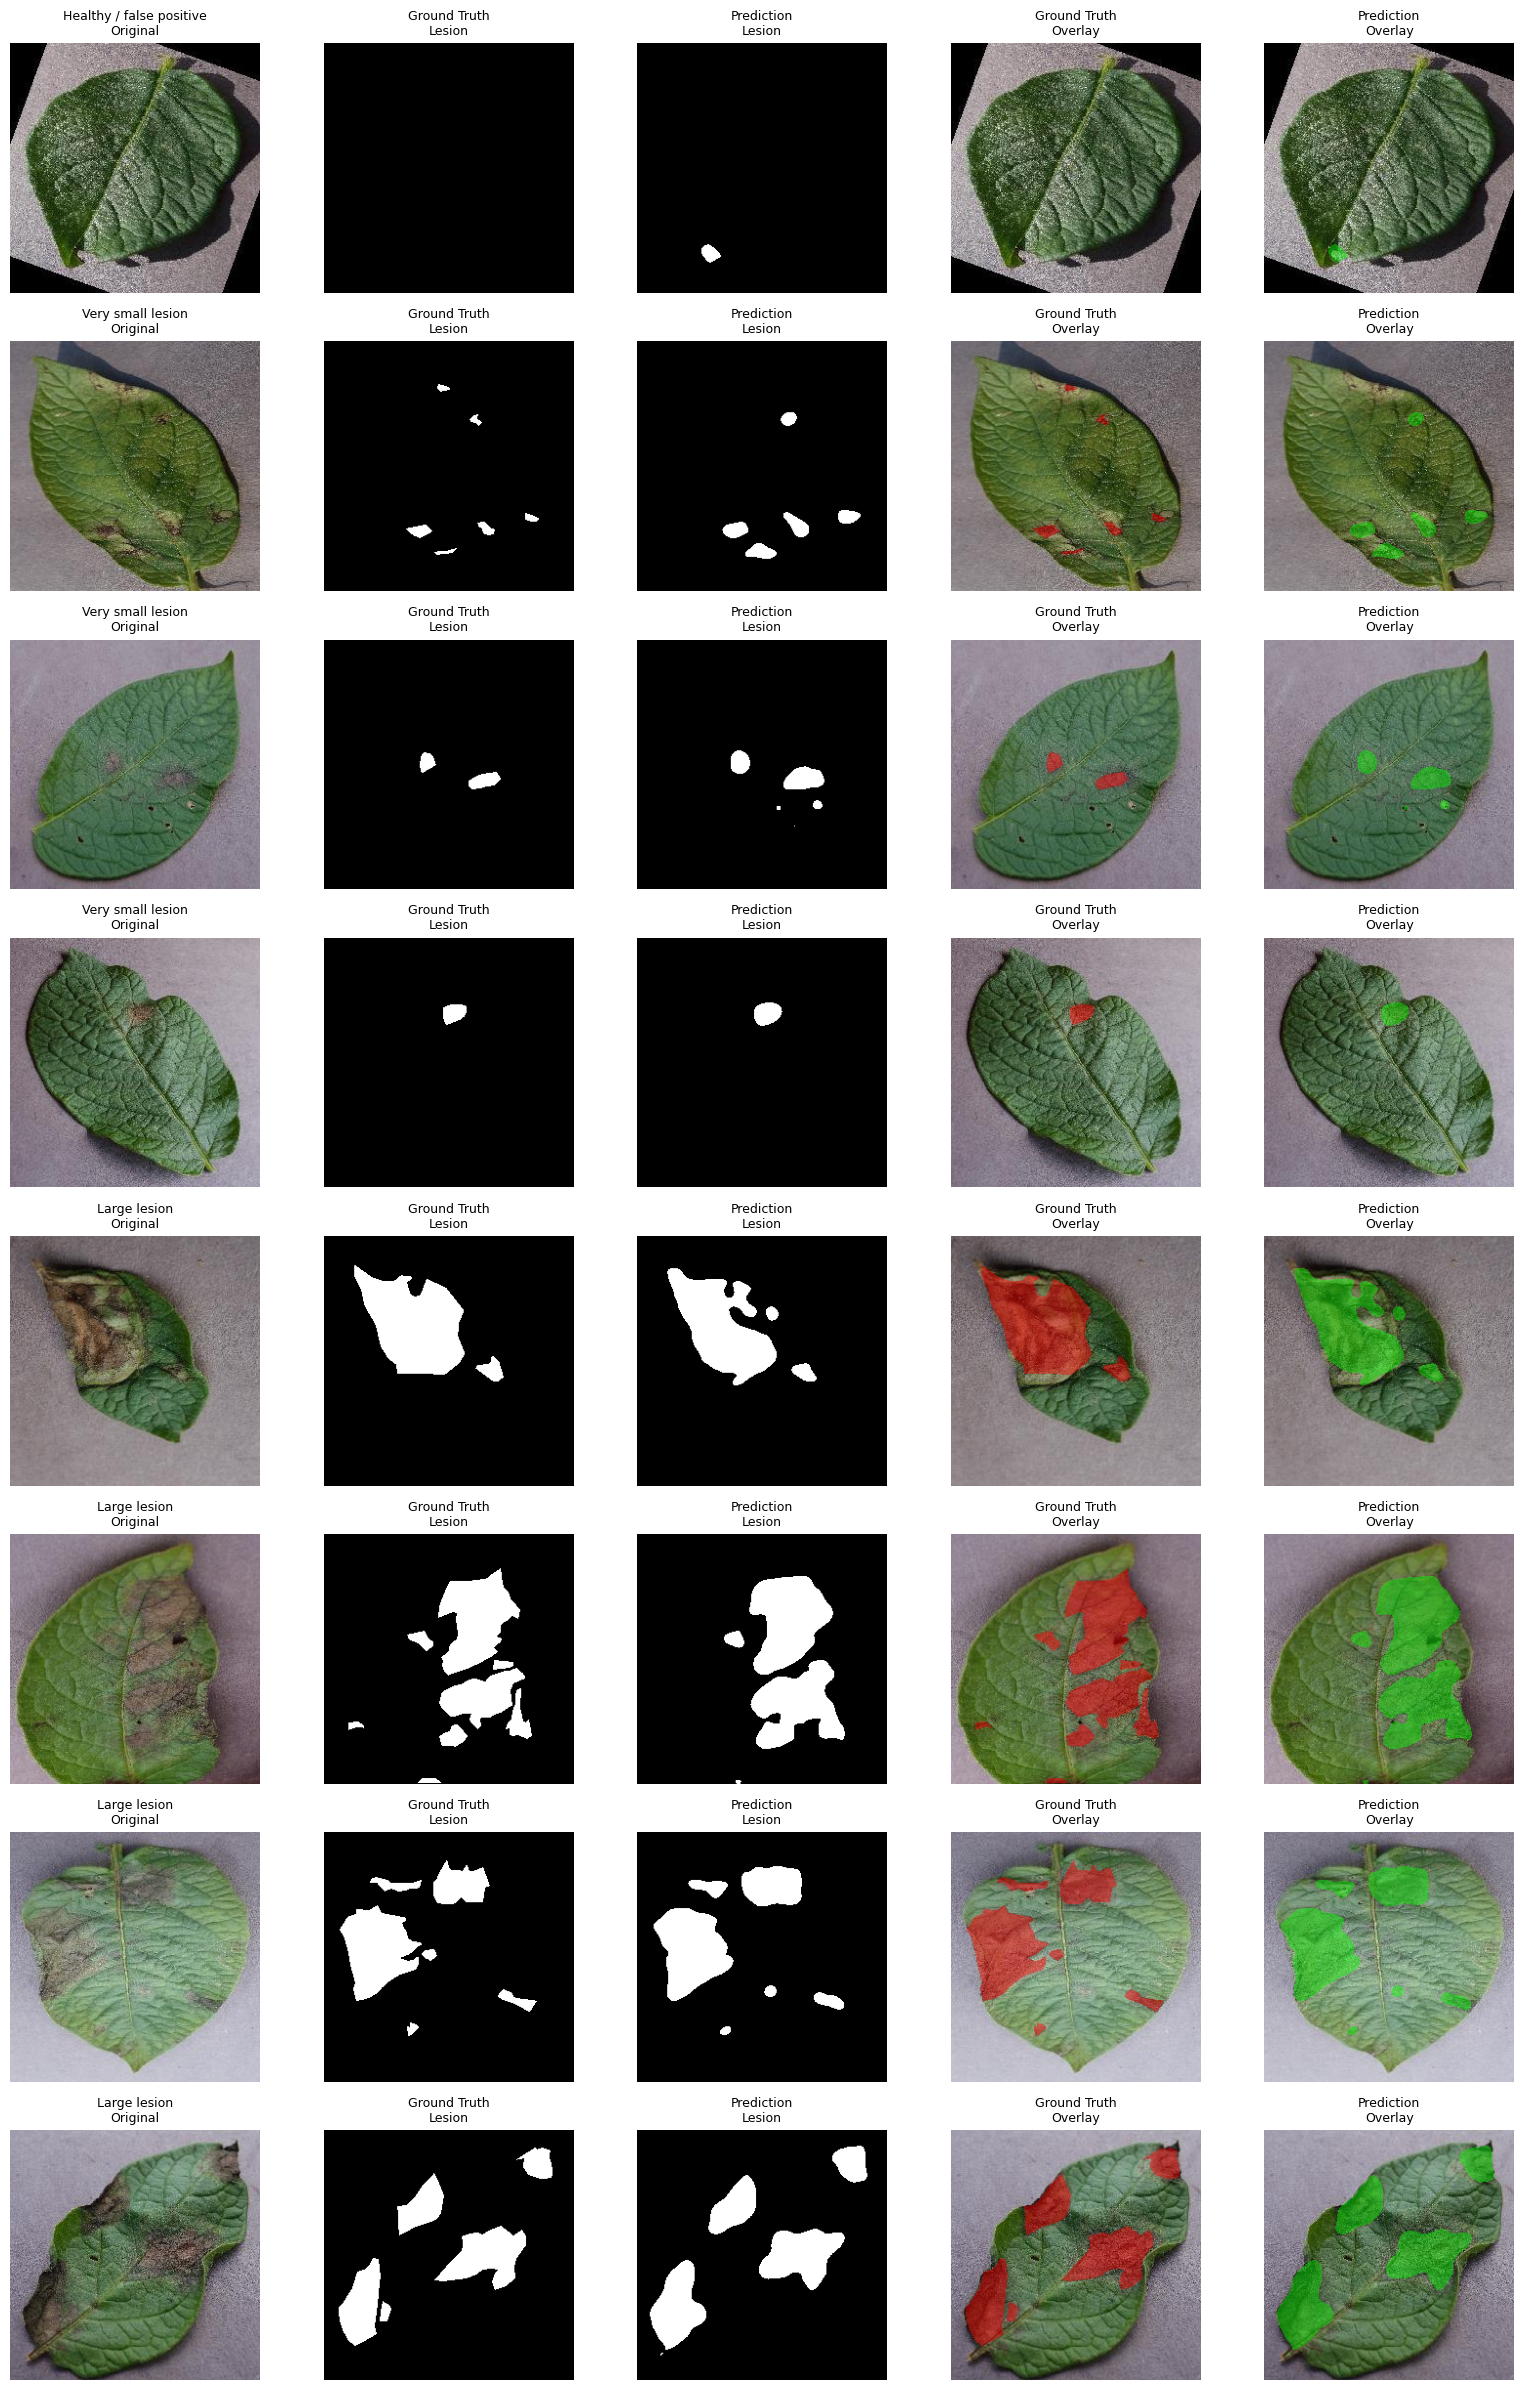

Qualitative figure saved to: /content/drive/MyDrive/Week2_Potato_Baseline_Outputs/week2_qualitative_examples.png

WEEK 1 PILOT vs WEEK 2 LARGER RE-RUN


,Experiment,Dataset Size,mIoU,Lesion IoU,Boundary F1,Loss,N_images
0,Week 1 Pilot,Pilot subset; exact total/training subset size...,0.913506,0.837611,0.780267,0.604585,106
1,Week 2 Larger Re-run,1108 total / 106 test (QC-usable: 1108),0.913410,0.835003,0.864355,0.538964,106


,Metric,Week1,Week2,Absolute change,Relative change
0,mIoU,0.913506,0.913410,-0.000095,-0.000104
1,Lesion IoU,0.837611,0.835003,-0.002608,-0.003114
2,Boundary F1,0.780267,0.864355,0.084088,0.107768
3,Loss,0.604585,0.538964,-0.065621,-0.108539



ERROR ANALYSIS COUNTS
Healthy cases with any predicted lesion pixels : 1
Lesion cases with zero predicted lesion pixels : 0
Very small-lesion test cases                 : 3
Large-lesion test cases                      : 16

Lowest-IoU examples selected for inspection:


,filename,gt_lesion_ratio,pred_lesion_ratio,lesion_IoU,Dice,Boundary_F1
34,269_Potato_Healthy_train_JPG.rf.f27cec17931277...,0.000000,0.003677,0.000000,0.000000,0.000000
66,385_Potato_Late_Blight_train_JPG.rf.9722c2e91a...,0.009918,0.022598,0.366902,0.536837,0.565382
79,427_Potato_Late_Blight_train_JPG.rf.29f495de4c...,0.015396,0.027176,0.479321,0.648029,0.666667
12,157_Potato_Late_Blight_train_JPG.rf.4b01d88de9...,0.009674,0.018860,0.490040,0.657754,0.514618
89,55_Potato_Late_Blight_train_V2_JPG.rf.2d703d0f...,0.011810,0.018372,0.573588,0.729019,0.760178
63,37_Potato_Late_Blight_val_JPG.rf.0bebfe2bd9227...,0.075500,0.067032,0.618330,0.764158,0.604630
39,298_Potato_Late_Blight_train_JPG.rf.68aabb3b94...,0.034317,0.053513,0.624612,0.768937,0.653458
56,346_Potato_Late_Blight_train_JPG.rf.fc5e082d96...,0.019058,0.020447,0.635502,0.777134,0.593788
29,251_Potato_Late_Blight_train_JPG.rf.352b67973c...,0.057053,0.068451,0.647966,0.786383,0.672284
58,353_Potato_Late_Blight_train_JPG.rf.1c96471757...,0.042114,0.060623,0.656335,0.792514,0.480977


In [23]:
# ============================================================
# SECTION 5 — Qualitative Results, Error Analysis and
#             Pilot Comparison
# ============================================================

import matplotlib.pyplot as plt

# -----------------------------
# 1. Helper: unnormalize image
# -----------------------------
MEAN_NP = np.array(
    IMAGENET_MEAN,
    dtype=np.float32,
).reshape(1, 1, 3)

STD_NP = np.array(
    IMAGENET_STD,
    dtype=np.float32,
).reshape(1, 1, 3)


def unnormalize_image(tensor):
    image = (
        tensor.detach()
        .cpu()
        .permute(1, 2, 0)
        .numpy()
    )

    image = (
        image * STD_NP +
        MEAN_NP
    )

    return np.clip(
        image,
        0,
        1,
    )


# -----------------------------
# 2. Overlay helper
# -----------------------------
def overlay_mask(
    image,
    mask,
    color=(1.0, 0.0, 0.0),
    alpha=0.45,
):

    output = image.copy()

    mask = mask.astype(bool)

    color_np = np.array(
        color,
        dtype=np.float32,
    ).reshape(1, 1, 3)

    output[mask] = (
        (1.0 - alpha) *
        output[mask]
        +
        alpha *
        color_np.reshape(3)
    )

    return np.clip(
        output,
        0,
        1,
    )


# -----------------------------
# 3. Map filename -> dataset index
# -----------------------------
test_filename_to_index = {
    record["filename"]: idx
    for idx, record
    in enumerate(USABLE_RECORDS["test"])
}


@torch.no_grad()
def get_visual_prediction(index):

    image_tensor, gt_tensor, filename = (
        test_dataset[index]
    )

    input_tensor = (
        image_tensor
        .unsqueeze(0)
        .to(DEVICE)
    )

    logits = model(input_tensor)

    pred = (
        torch.sigmoid(logits)[0, 0]
        .cpu()
        .numpy()
        >= THRESHOLD
    )

    image = unnormalize_image(
        image_tensor
    )

    gt = (
        gt_tensor[0]
        .cpu()
        .numpy()
        >= 0.5
    )

    return image, gt, pred, filename


# -----------------------------
# 4. Select representative examples
# -----------------------------
df = TEST_PER_IMAGE_DF.copy()

selected = []
selected_labels = []


def add_example_from_df(
    candidate_df,
    label,
    max_items=1,
):

    if candidate_df.empty:
        return

    for _, row in candidate_df.iterrows():

        filename = row["filename"]

        if filename in selected:
            continue

        selected.append(filename)
        selected_labels.append(label)

        if len(selected_labels) >= 8:
            return


# A. Healthy + false positive
healthy_fp = df[
    (df["gt_lesion_pixels"] == 0)
    &
    (df["pred_lesion_pixels"] > 0)
].sort_values(
    "pred_lesion_pixels",
    ascending=False,
)

add_example_from_df(
    healthy_fp,
    "Healthy / false positive",
)

# B. Missed lesion
missed = df[
    (df["gt_lesion_pixels"] > 0)
    &
    (df["pred_lesion_pixels"] == 0)
].sort_values(
    "gt_lesion_pixels",
    ascending=False,
)

add_example_from_df(
    missed,
    "Lesion completely missed",
)

# C. Very small lesion
small_lesion = df[
    (df["gt_lesion_ratio"] > 0)
    &
    (df["gt_lesion_ratio"] <= 0.01)
].sort_values(
    "lesion_IoU"
)

add_example_from_df(
    small_lesion,
    "Very small lesion",
)

# D. Large lesion
large_lesion = df[
    df["gt_lesion_ratio"] >= 0.10
].sort_values(
    "lesion_IoU"
)

add_example_from_df(
    large_lesion,
    "Large lesion",
)

# E. Highest-error
high_error = df.sort_values(
    "lesion_IoU"
)

add_example_from_df(
    high_error,
    "High-error case",
)

# F. Good segmentation
good_cases = df.sort_values(
    "lesion_IoU",
    ascending=False,
)

add_example_from_df(
    good_cases,
    "Good segmentation",
)

# Ensure a few additional examples if categories were sparse.
add_example_from_df(
    df.sort_values("Boundary_F1"),
    "Boundary-error case",
)

add_example_from_df(
    df.sort_values("Dice", ascending=False),
    "High-overlap case",
)

selected = selected[:8]
selected_labels = selected_labels[:8]

# -----------------------------
# 5. Qualitative grid
# -----------------------------
if len(selected) == 0:
    print(
        "No representative examples could be selected."
    )
else:

    n = len(selected)

    fig, axes = plt.subplots(
        nrows=n,
        ncols=5,
        figsize=(16, max(3 * n, 5)),
    )

    axes = np.atleast_2d(axes)

    for row_idx, filename in enumerate(selected):

        idx = test_filename_to_index[
            filename
        ]

        image, gt, pred, _ = (
            get_visual_prediction(idx)
        )

        gt_overlay = overlay_mask(
            image,
            gt,
            color=(1.0, 0.0, 0.0),
            alpha=0.45,
        )

        pred_overlay = overlay_mask(
            image,
            pred,
            color=(0.0, 1.0, 0.0),
            alpha=0.45,
        )

        visuals = [
            image,
            gt,
            pred,
            gt_overlay,
            pred_overlay,
        ]

        titles = [
            f"{selected_labels[row_idx]}\nOriginal",
            "Ground Truth\nLesion",
            "Prediction\nLesion",
            "Ground Truth\nOverlay",
            "Prediction\nOverlay",
        ]

        for col_idx, (ax, visual, title) in enumerate(
            zip(
                axes[row_idx],
                visuals,
                titles,
            )
        ):

            if visual.ndim == 2:
                ax.imshow(
                    visual,
                    cmap="gray",
                )
            else:
                ax.imshow(visual)

            ax.set_title(
                title,
                fontsize=9,
            )

            ax.axis("off")

        axes[row_idx, 0].set_ylabel(
            filename[:24],
            fontsize=8,
        )

    plt.tight_layout()

    qualitative_path = (
        OUTPUT_DIR /
        "week2_qualitative_examples.png"
    )

    plt.savefig(
        qualitative_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"Qualitative figure saved to: "
        f"{qualitative_path}"
    )


# -----------------------------
# 6. Week 1 vs Week 2 comparison
# -----------------------------
week1_row = {
    "Experiment": "Week 1 Pilot",
    "Dataset Size": WEEK1_DATASET_SIZE_NOTE,
    "mIoU": WEEK1_PILOT["mIoU"],
    "Lesion IoU": WEEK1_PILOT["Lesion IoU"],
    "Boundary F1": WEEK1_PILOT["Boundary F1"],
    "Loss": WEEK1_PILOT["Loss"],
    "N_images": WEEK1_PILOT["N_images"],
}

week2_row = {
    "Experiment": "Week 2 Larger Re-run",
    "Dataset Size": (
        f"{EXPECTED_TOTAL} total / "
        f"{len(test_dataset)} test "
        f"(QC-usable: "
        f"{sum(len(v) for v in USABLE_RECORDS.values())})"
    ),
    "mIoU": TEST_METRICS["mIoU"],
    "Lesion IoU": TEST_METRICS["Lesion IoU"],
    "Boundary F1": TEST_METRICS["Boundary F1"],
    "Loss": TEST_METRICS["Loss"],
    "N_images": TEST_METRICS["N_images"],
}

COMPARISON_DF = pd.DataFrame([
    week1_row,
    week2_row,
])

print("\n" + "=" * 70)
print("WEEK 1 PILOT vs WEEK 2 LARGER RE-RUN")
print("=" * 70)

display(COMPARISON_DF)

# -----------------------------
# 7. Metric deltas
# -----------------------------
delta_rows = []

for metric in [
    "mIoU",
    "Lesion IoU",
    "Boundary F1",
    "Loss",
]:

    delta = (
        week2_row[metric]
        -
        week1_row[metric]
    )

    if week1_row[metric] != 0:
        relative_change = (
            delta /
            week1_row[metric]
        )
    else:
        relative_change = np.nan

    delta_rows.append({
        "Metric": metric,
        "Week1": week1_row[metric],
        "Week2": week2_row[metric],
        "Absolute change": delta,
        "Relative change": relative_change,
    })

DELTA_DF = pd.DataFrame(
    delta_rows
)

display(DELTA_DF)

# -----------------------------
# 8. Error-category counts
# -----------------------------
print("\n" + "=" * 70)
print("ERROR ANALYSIS COUNTS")
print("=" * 70)

print(
    "Healthy cases with any predicted lesion pixels :",
    int(
        (
            (df["gt_lesion_pixels"] == 0)
            &
            (df["pred_lesion_pixels"] > 0)
        ).sum()
    )
)

print(
    "Lesion cases with zero predicted lesion pixels :",
    int(
        (
            (df["gt_lesion_pixels"] > 0)
            &
            (df["pred_lesion_pixels"] == 0)
        ).sum()
    )
)

print(
    "Very small-lesion test cases                 :",
    int(
        (
            (df["gt_lesion_ratio"] > 0)
            &
            (df["gt_lesion_ratio"] <= 0.01)
        ).sum()
    )
)

print(
    "Large-lesion test cases                      :",
    int(
        (df["gt_lesion_ratio"] >= 0.10).sum()
    )
)

print(
    "\nLowest-IoU examples selected for inspection:"
)

display(
    df[
        [
            "filename",
            "gt_lesion_ratio",
            "pred_lesion_ratio",
            "lesion_IoU",
            "Dice",
            "Boundary_F1",
        ]
    ]
    .sort_values("lesion_IoU")
    .head(10)
)

# **SECTION 6 — Final Research Report and Reproducibility Summary**

In [24]:
# ============================================================
# SECTION 6 — Final Research Report and Reproducibility
#             Summary
# ============================================================

import json
import pandas as pd
from pathlib import Path

# -----------------------------
# 1. Final metrics table
# -----------------------------
FINAL_RESULTS = {
    "Experiment": (
        "Week 2 — Larger-Subset Re-run of "
        "Week 1 Image-only Baseline"
    ),

    "Dataset": "Potato_Severity_Dataset_DEDUPED_FINAL",

    "Train": len(train_dataset),
    "Validation": len(valid_dataset),
    "Test": len(test_dataset),

    "Model": "EfficientNet-B0 U-Net",

    "Input": "RGB image only",

    "Target": "Binary late-blight lesion mask",

    "mIoU": TEST_METRICS["mIoU"],
    "Lesion IoU": TEST_METRICS["Lesion IoU"],
    "Boundary F1": TEST_METRICS["Boundary F1"],
    "Dice": TEST_METRICS["Dice"],
    "Precision": TEST_METRICS["Precision"],
    "Recall": TEST_METRICS["Recall"],
    "Test Loss": TEST_METRICS["Loss"],
    "N_images": TEST_METRICS["N_images"],
}

RESULTS_DF = pd.DataFrame([
    FINAL_RESULTS
])

# Required final metric CSV.
RESULT_CSV_PATH = (
    OUTPUT_DIR /
    "week2_baseline_validation_results.csv"
)

RESULTS_DF.to_csv(
    RESULT_CSV_PATH,
    index=False,
)

# -----------------------------
# 2. Save complete configuration
# -----------------------------
FINAL_CONFIG = {
    "experiment": (
        "Week 2 — Larger-Subset Re-run of "
        "Week 1 Image-only Baseline"
    ),

    "dataset": "Potato_Severity_Dataset_DEDUPED_FINAL",

    "dataset_root": str(DATASET_ROOT),

    "seed": SEED,

    "train_count_expected": EXPECTED_COUNTS["train"],
    "valid_count_expected": EXPECTED_COUNTS["valid"],
    "test_count_expected": EXPECTED_COUNTS["test"],

    "train_count_usable": len(train_dataset),
    "valid_count_usable": len(valid_dataset),
    "test_count_usable": len(test_dataset),

    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,

    "model": "EfficientNet-B0 U-Net",
    "pretrained": PRETRAINED,

    "normalization": {
        "mean": IMAGENET_MEAN,
        "std": IMAGENET_STD,
    },

    "augmentation": {
        "training_only": True,
        "horizontal_flip": 0.50,
        "vertical_flip": 0.20,
        "random_rotate90": 0.30,
        "shift_scale_rotate": True,
        "brightness_contrast": 0.20,
    },

    "loss": {
        "type": "BCEWithLogits + Dice",
        "bce_weight": BCE_WEIGHT,
        "dice_weight": DICE_WEIGHT,
    },

    "optimizer": {
        "type": "AdamW",
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
    },

    "scheduler": {
        "type": "ReduceLROnPlateau",
        "mode": "max",
        "factor": 0.5,
        "patience": 3,
        "monitor": "validation lesion IoU",
    },

    "epochs": EPOCHS,

    "threshold": THRESHOLD,

    "boundary_f1": {
        "tolerance_pixels": BOUNDARY_TOLERANCE,
        "boundary_definition": (
            "binary mask XOR 3x3 morphological erosion"
        ),
    },

    "test_set_used_for_model_selection": False,

    "exact_week1_configuration_available": False,

    "configuration_note": (
        "Image size, augmentation, optimizer, learning rate, "
        "scheduler and threshold are explicit reproducible "
        "assumptions unless replaced with exact Week 1 settings."
    ),

    "best_epoch": int(checkpoint["epoch"]),
    "best_validation_lesion_iou": float(
        checkpoint["best_val_lesion_iou"]
    ),
}

CONFIG_PATH = (
    OUTPUT_DIR /
    "week2_baseline_config.json"
)

with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        FINAL_CONFIG,
        f,
        indent=2,
    )

# -----------------------------
# 3. Automatically generate
#    pilot comparison conclusion
# -----------------------------
PRIMARY_METRICS = [
    "mIoU",
    "Lesion IoU",
    "Boundary F1",
]

ABS_TOLERANCE = 0.03
SUBSTANTIAL_CHANGE = 0.08

metric_deltas = {
    metric:
        float(
            week2_row[metric]
            -
            week1_row[metric]
        )
    for metric in PRIMARY_METRICS
}

within_tolerance = all(
    abs(metric_deltas[m])
    <= ABS_TOLERANCE
    for m in PRIMARY_METRICS
)

substantial_drop = any(
    metric_deltas[m]
    <= -SUBSTANTIAL_CHANGE
    for m in PRIMARY_METRICS
)

substantial_gain = any(
    metric_deltas[m]
    >= SUBSTANTIAL_CHANGE
    for m in PRIMARY_METRICS
)

if within_tolerance:

    reproduction_status = (
        "approximately reproduced"
    )

elif substantial_drop and not substantial_gain:

    reproduction_status = (
        "substantially reduced"
    )

elif substantial_gain and not substantial_drop:

    reproduction_status = (
        "substantially improved"
    )

else:

    reproduction_status = (
        "inconclusive / mixed"
    )


if reproduction_status == "approximately reproduced":

    q1 = (
        "1. Was the Week 1 pilot approximately reproduced?\n"
        "Yes. The three primary metrics are all within the "
        f"predeclared ±{ABS_TOLERANCE:.2f} absolute tolerance "
        "of the stored Week 1 pilot values."
    )

    q2 = (
        "\n2. Is there evidence that the pilot result was a "
        "small-sample artifact?\n"
        "No strong evidence is provided by this re-run. "
        "The larger training set reproduced pilot-level "
        "performance. This is evidence against the result "
        "being purely a small-sample artifact, but one run "
        "does not prove generalization."
    )

elif reproduction_status == "substantially reduced":

    q1 = (
        "1. Was the Week 1 pilot approximately reproduced?\n"
        "No. The larger re-run shows a substantial reduction "
        "in at least one primary metric."
    )

    q2 = (
        "\n2. Is there evidence that the pilot result was a "
        "small-sample artifact?\n"
        "There is evidence that the pilot performance was "
        "sensitive to the larger training/evaluation setup, "
        "which is consistent with a possible small-sample "
        "effect. It does not prove that explanation."
    )

elif reproduction_status == "substantially improved":

    q1 = (
        "1. Was the Week 1 pilot approximately reproduced?\n"
        "No. The larger re-run materially improves at least "
        "one primary metric rather than reproducing the pilot "
        "level."
    )

    q2 = (
        "\n2. Is there evidence that the pilot result was a "
        "small-sample artifact?\n"
        "This re-run does not provide evidence that the pilot "
        "performance was an inflated small-sample artifact. "
        "The larger dataset instead produced stronger "
        "performance."
    )

else:

    q1 = (
        "1. Was the Week 1 pilot approximately reproduced?\n"
        "Inconclusive. The primary metrics changed in mixed "
        "directions or by different magnitudes."
    )

    q2 = (
        "\n2. Is there evidence that the pilot result was a "
        "small-sample artifact?\n"
        "Not enough evidence to determine this cleanly from "
        "one larger-subset run."
    )


q3 = (
    "\n3. What changed between the pilot and the larger experiment?\n"
    f"The Week 2 run trains on all QC-usable samples available "
    f"in the final train split ({len(train_dataset)}), evaluates "
    f"on the final validation split ({len(valid_dataset)}), and "
    f"uses the untouched test split ({len(test_dataset)}). "
    "The experiment remains strictly image-only. "
    "The important methodological caveat is that the exact "
    "Week 1 image size, augmentation, optimizer/schedule and "
    "threshold were not available here; therefore any metric "
    "difference cannot automatically be attributed to dataset "
    "size alone until those settings are matched exactly."
)

q4 = (
    "\n4. What should be used as the image-only baseline for the "
    "next multimodal experiment?\n"
    "Use the Week 2 larger-dataset checkpoint and its frozen "
    "preprocessing/evaluation configuration as the image-only "
    "baseline. Keep the test set fixed and untouched when "
    "comparing the subsequent multimodal model."
)

conclusion = (
    f"Overall classification: {reproduction_status}\n\n"
    f"{q1}\n"
    f"{q2}\n"
    f"{q3}\n"
    f"{q4}\n"
)

# -----------------------------
# 4. Save conclusion
# -----------------------------
CONCLUSION_PATH = (
    OUTPUT_DIR /
    "week2_research_conclusion.txt"
)

with open(
    CONCLUSION_PATH,
    "w",
    encoding="utf-8",
) as f:
    f.write(conclusion)

# -----------------------------
# 5. Final summary printout
# -----------------------------
print("\n" + "=" * 76)
print("FINAL RESEARCH SUMMARY")
print("=" * 76)

print(
    "\nExperiment:\n"
    "Week 2 — Larger-Subset Re-run of Week 1 Image-only Baseline"
)

print("\nDataset:")
print("Potato_Severity_Dataset_DEDUPED_FINAL")

print(f"\nTrain       : {len(train_dataset)}")
print(f"Validation  : {len(valid_dataset)}")
print(f"Test        : {len(test_dataset)}")

print("\nModel:")
print("EfficientNet-B0 U-Net")

print("\nInput:")
print("RGB image only")

print("\nTarget:")
print("Binary late-blight lesion mask")

print(f"\nmIoU        : {TEST_METRICS['mIoU']:.6f}")
print(f"Lesion IoU  : {TEST_METRICS['Lesion IoU']:.6f}")
print(f"Boundary F1 : {TEST_METRICS['Boundary F1']:.6f}")
print(f"Dice        : {TEST_METRICS['Dice']:.6f}")
print(f"Precision   : {TEST_METRICS['Precision']:.6f}")
print(f"Recall      : {TEST_METRICS['Recall']:.6f}")
print(f"Test Loss   : {TEST_METRICS['Loss']:.6f}")
print(f"N_images    : {TEST_METRICS['N_images']}")

print("\n" + "=" * 76)
print("PILOT COMPARISON")
print("=" * 76)

display(COMPARISON_DF)

print(
    "\nMetric changes relative to Week 1 pilot:"
)

for metric, delta in metric_deltas.items():
    print(
        f"  {metric:15s}: "
        f"{delta:+.6f}"
    )

print("\n" + "=" * 76)
print("RESEARCH CONCLUSION")
print("=" * 76)

print(conclusion)

# -----------------------------
# 6. Output inventory
# -----------------------------
print("=" * 76)
print("OUTPUT FILES")
print("=" * 76)

for path in sorted(OUTPUT_DIR.glob("week2_*")):
    if path.is_file():
        print(
            f"{path.name:50s} "
            f"{path.stat().st_size / 1024:.1f} KB"
        )

print("\nRequired files:")
print(f"  Best checkpoint : {BEST_CKPT_PATH}")
print(f"  Results CSV     : {RESULT_CSV_PATH}")
print(f"  Config JSON     : {CONFIG_PATH}")
print(f"  Conclusion      : {CONCLUSION_PATH}")


FINAL RESEARCH SUMMARY

Experiment:
Week 2 — Larger-Subset Re-run of Week 1 Image-only Baseline

Dataset:
Potato_Severity_Dataset_DEDUPED_FINAL

Train       : 895
Validation  : 107
Test        : 106

Model:
EfficientNet-B0 U-Net

Input:
RGB image only

Target:
Binary late-blight lesion mask

mIoU        : 0.913410
Lesion IoU  : 0.835003
Boundary F1 : 0.864355
Dice        : 0.910084
Precision   : 0.874983
Recall      : 0.948118
Test Loss   : 0.538964
N_images    : 106

PILOT COMPARISON


,Experiment,Dataset Size,mIoU,Lesion IoU,Boundary F1,Loss,N_images
0,Week 1 Pilot,Pilot subset; exact total/training subset size...,0.913506,0.837611,0.780267,0.604585,106
1,Week 2 Larger Re-run,1108 total / 106 test (QC-usable: 1108),0.913410,0.835003,0.864355,0.538964,106



Metric changes relative to Week 1 pilot:
  mIoU           : -0.000095
  Lesion IoU     : -0.002608
  Boundary F1    : +0.084088

RESEARCH CONCLUSION
Overall classification: substantially improved

1. Was the Week 1 pilot approximately reproduced?
No. The larger re-run materially improves at least one primary metric rather than reproducing the pilot level.

2. Is there evidence that the pilot result was a small-sample artifact?
This re-run does not provide evidence that the pilot performance was an inflated small-sample artifact. The larger dataset instead produced stronger performance.

3. What changed between the pilot and the larger experiment?
The Week 2 run trains on all QC-usable samples available in the final train split (895), evaluates on the final validation split (107), and uses the untouched test split (106). The experiment remains strictly image-only. The important methodological caveat is that the exact Week 1 image size, augmentation, optimizer/schedule and threshold wer